In [1]:
!pip install ultralytics kagglehub
from ultralytics import YOLO
import os, shutil, random, yaml, cv2, kagglehub, glob, json
from IPython.display import Image, display
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


/home/eurico/arquivos/caries-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("truthisneverlinear/dentex-challenge-2023")
path

'/home/eurico/.cache/kagglehub/datasets/truthisneverlinear/dentex-challenge-2023/versions/1'

In [3]:
JSON = path + "/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
IMGS = path + "/training_data/training_data/quadrant-enumeration-disease/xrays/"
SAIDA = "dentex/data/"

CLASSES = {"Caries": 0, "Deep Caries": 0}   # 0,0 = classe unica; use 0,1 para separar

d = json.load(open(JSON))
diag = {c["id"]: c["name"] for c in d["categories_3"]}
imgs = {i["id"]: i for i in d["images"]}

os.makedirs(f"{SAIDA}/images", exist_ok=True)
os.makedirs(f"{SAIDA}/labels", exist_ok=True)

porimg = {}
for a in d["annotations"]:
    nome_diag = diag[a["category_id_3"]]
    if nome_diag not in CLASSES:
        continue
    im = imgs[a["image_id"]]
    x, y, bw, bh = a["bbox"]
    w, h = im["width"], im["height"]
    linha = "%d %.6f %.6f %.6f %.6f" % (CLASSES[nome_diag], (x+bw/2)/w, (y+bh/2)/h, bw/w, bh/h)
    porimg.setdefault(im["file_name"], []).append(linha)

for nome, linhas in porimg.items():
    shutil.copy(f"{IMGS}/{nome}", f"{SAIDA}/images/{nome}")
    open(f"{SAIDA}/labels/{os.path.splitext(nome)[0]}.txt", "w").write("\n".join(linhas))

print("imagens:", len(porimg), "| lesoes:", sum(len(v) for v in porimg.values()))

imagens: 650 | lesoes: 2767


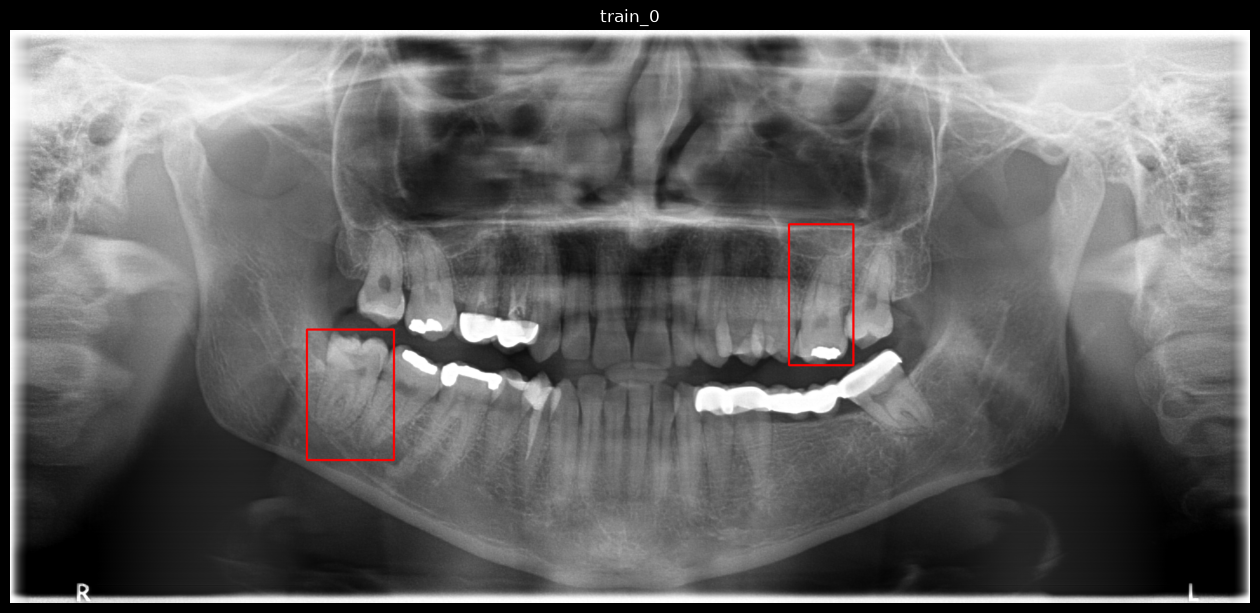

In [4]:
lab = "dentex/data/labels"
img_dir = "dentex/data/images"

arq = sorted(a for a in os.listdir(lab) if open(os.path.join(lab, a)).read().strip())[0]
stem = arq[:-4]
img = cv2.cvtColor(cv2.imread(f"{img_dir}/{stem}.png"), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

for linha in open(f"{lab}/{arq}").read().split("\n"):
    if not linha.strip():
        continue
    _, cx, cy, bw, bh = [float(v) for v in linha.split()]
    p1 = (int((cx-bw/2)*w), int((cy-bh/2)*h))
    p2 = (int((cx+bw/2)*w), int((cy+bh/2)*h))
    cv2.rectangle(img, p1, p2, (255, 0, 0), 4)

plt.figure(figsize=(16, 8)); plt.imshow(img); plt.title(stem); plt.axis("off"); plt.show()

In [5]:
dst = "dentex/data/"

pares = []
for img in sorted(os.listdir(dst + "/images")):
    rot = os.path.splitext(img)[0] + ".txt"
    if os.path.exists(dst + "/labels/" + rot):
        pares.append((img, rot))

random.Random(42).shuffle(pares)

N_VALID = 50
N_TEST = 100

divisoes = {
    "valid": pares[:N_VALID],
    "test":  pares[N_VALID:N_VALID + N_TEST],
    "train": pares[N_VALID + N_TEST:],
}

for split, itens in divisoes.items():
    os.makedirs(f"{dst}/{split}/images", exist_ok=True)
    os.makedirs(f"{dst}/{split}/labels", exist_ok=True)
    for img, rot in itens:
        shutil.move(f"{dst}/images/{img}", f"{dst}/{split}/images/{img}")
        shutil.move(f"{dst}/labels/{rot}", f"{dst}/{split}/labels/{rot}")
    print(split, len(itens))

shutil.rmtree(dst + "/images", ignore_errors=True)
shutil.rmtree(dst + "/labels", ignore_errors=True)

valid 50
test 100
train 500


In [6]:
CLASSES = ["carie"]

conteudo = {
    "path": dst,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i: nome for i, nome in enumerate(CLASSES)},
}

destino = os.path.join(dst, "data.yaml")
with open(destino, "w") as f:
    yaml.dump(conteudo, f, sort_keys=False, allow_unicode=True)

print(open(destino).read())

path: dentex/data/
train: train/images
val: valid/images
test: test/images
names:
  0: carie



In [7]:
model = YOLO("yolo11s.pt")

model.train(
    data=destino,
    epochs=150,
    imgsz=1024,
    batch=8,
    patience=20,
    seed=42,
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dentex/data/data.yaml, degrees=8.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f434611ede0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [9]:
m = model.val(data=destino, split="test")

print("mAP50:     %.4f" % m.box.map50)
print("mAP50-95:  %.4f" % m.box.map)
print("precisao:  %.4f" % m.box.mp)
print("recall:    %.4f" % m.box.mr)
print("F1:        %.4f" % (2*m.box.mp*m.box.mr / (m.box.mp+m.box.mr)))
print("\nvelocidade (ms/imagem):", {k: round(v,1) for k,v in m.speed.items()})

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 7806MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6377.8±2593.7 MB/s, size: 4287.9 KB)
val: Scanning /home/eurico/arquivos/caries-detection/notebooks/dentex/data/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 35.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.4it/s 1.3s0.1ss
                   all        100        447       0.61      0.479      0.395      0.257
Speed: 1.5ms preprocess, 2.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /home/eurico/arquivos/caries-detection/notebooks/runs/detect/val-3
mAP50:     0.3953
mAP50-95:  0.2572
precisao:  0.6097
recall:    0.4787
F1:        0.5363

velocidade (ms/imagem): {'preprocess': 1.5, 'inference': 2.8, 'loss': 0.0, 'postprocess': 1.0}


runs/detect/train-3

=== results.png


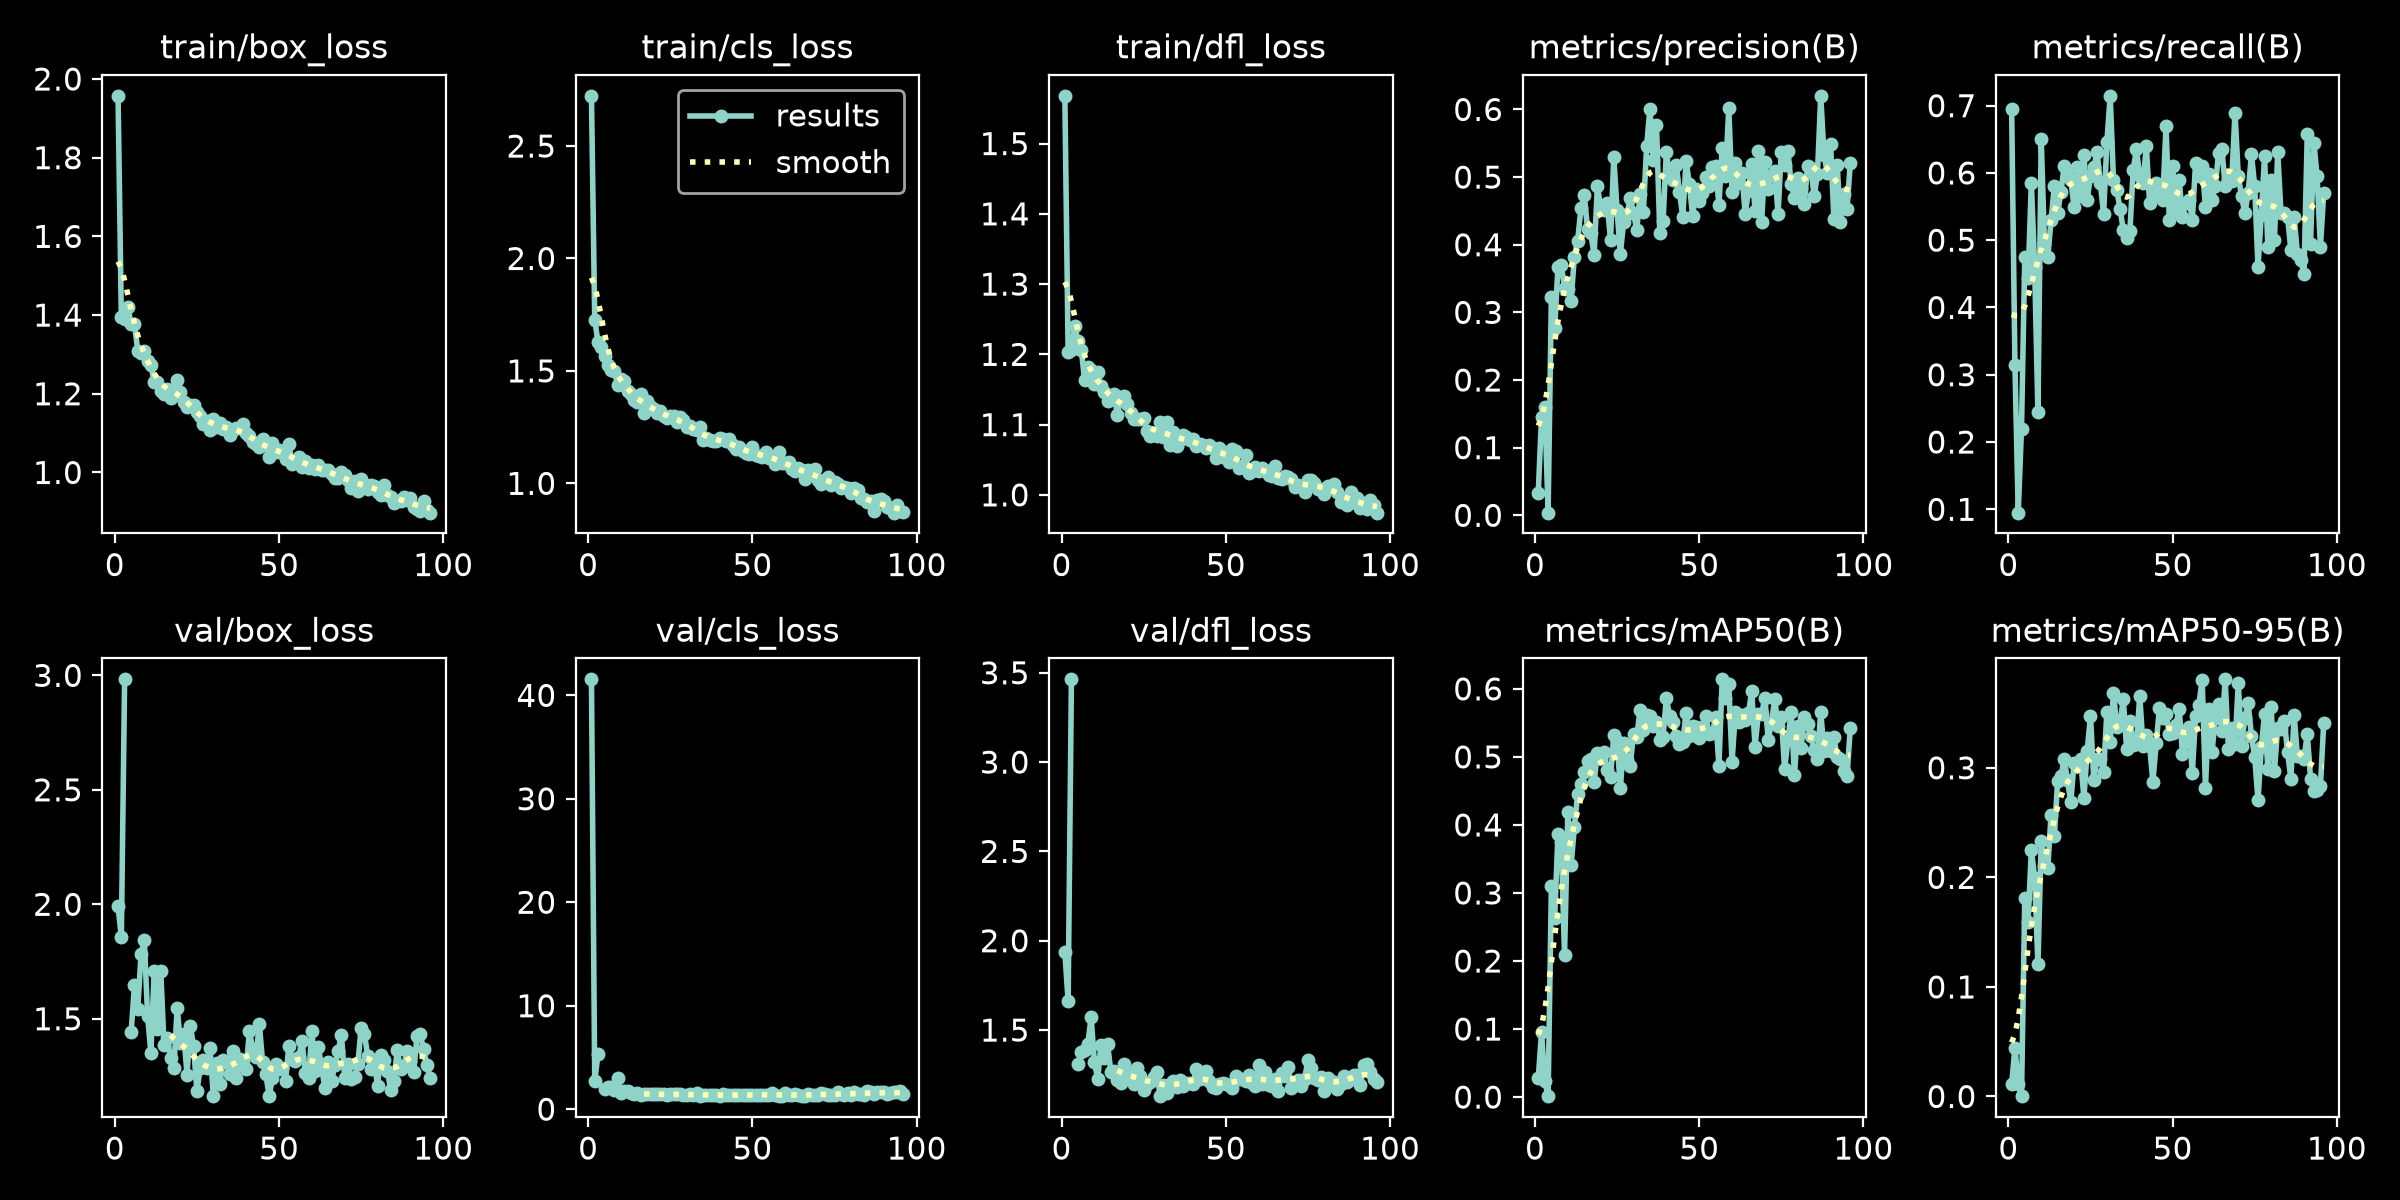


=== confusion_matrix_normalized.png


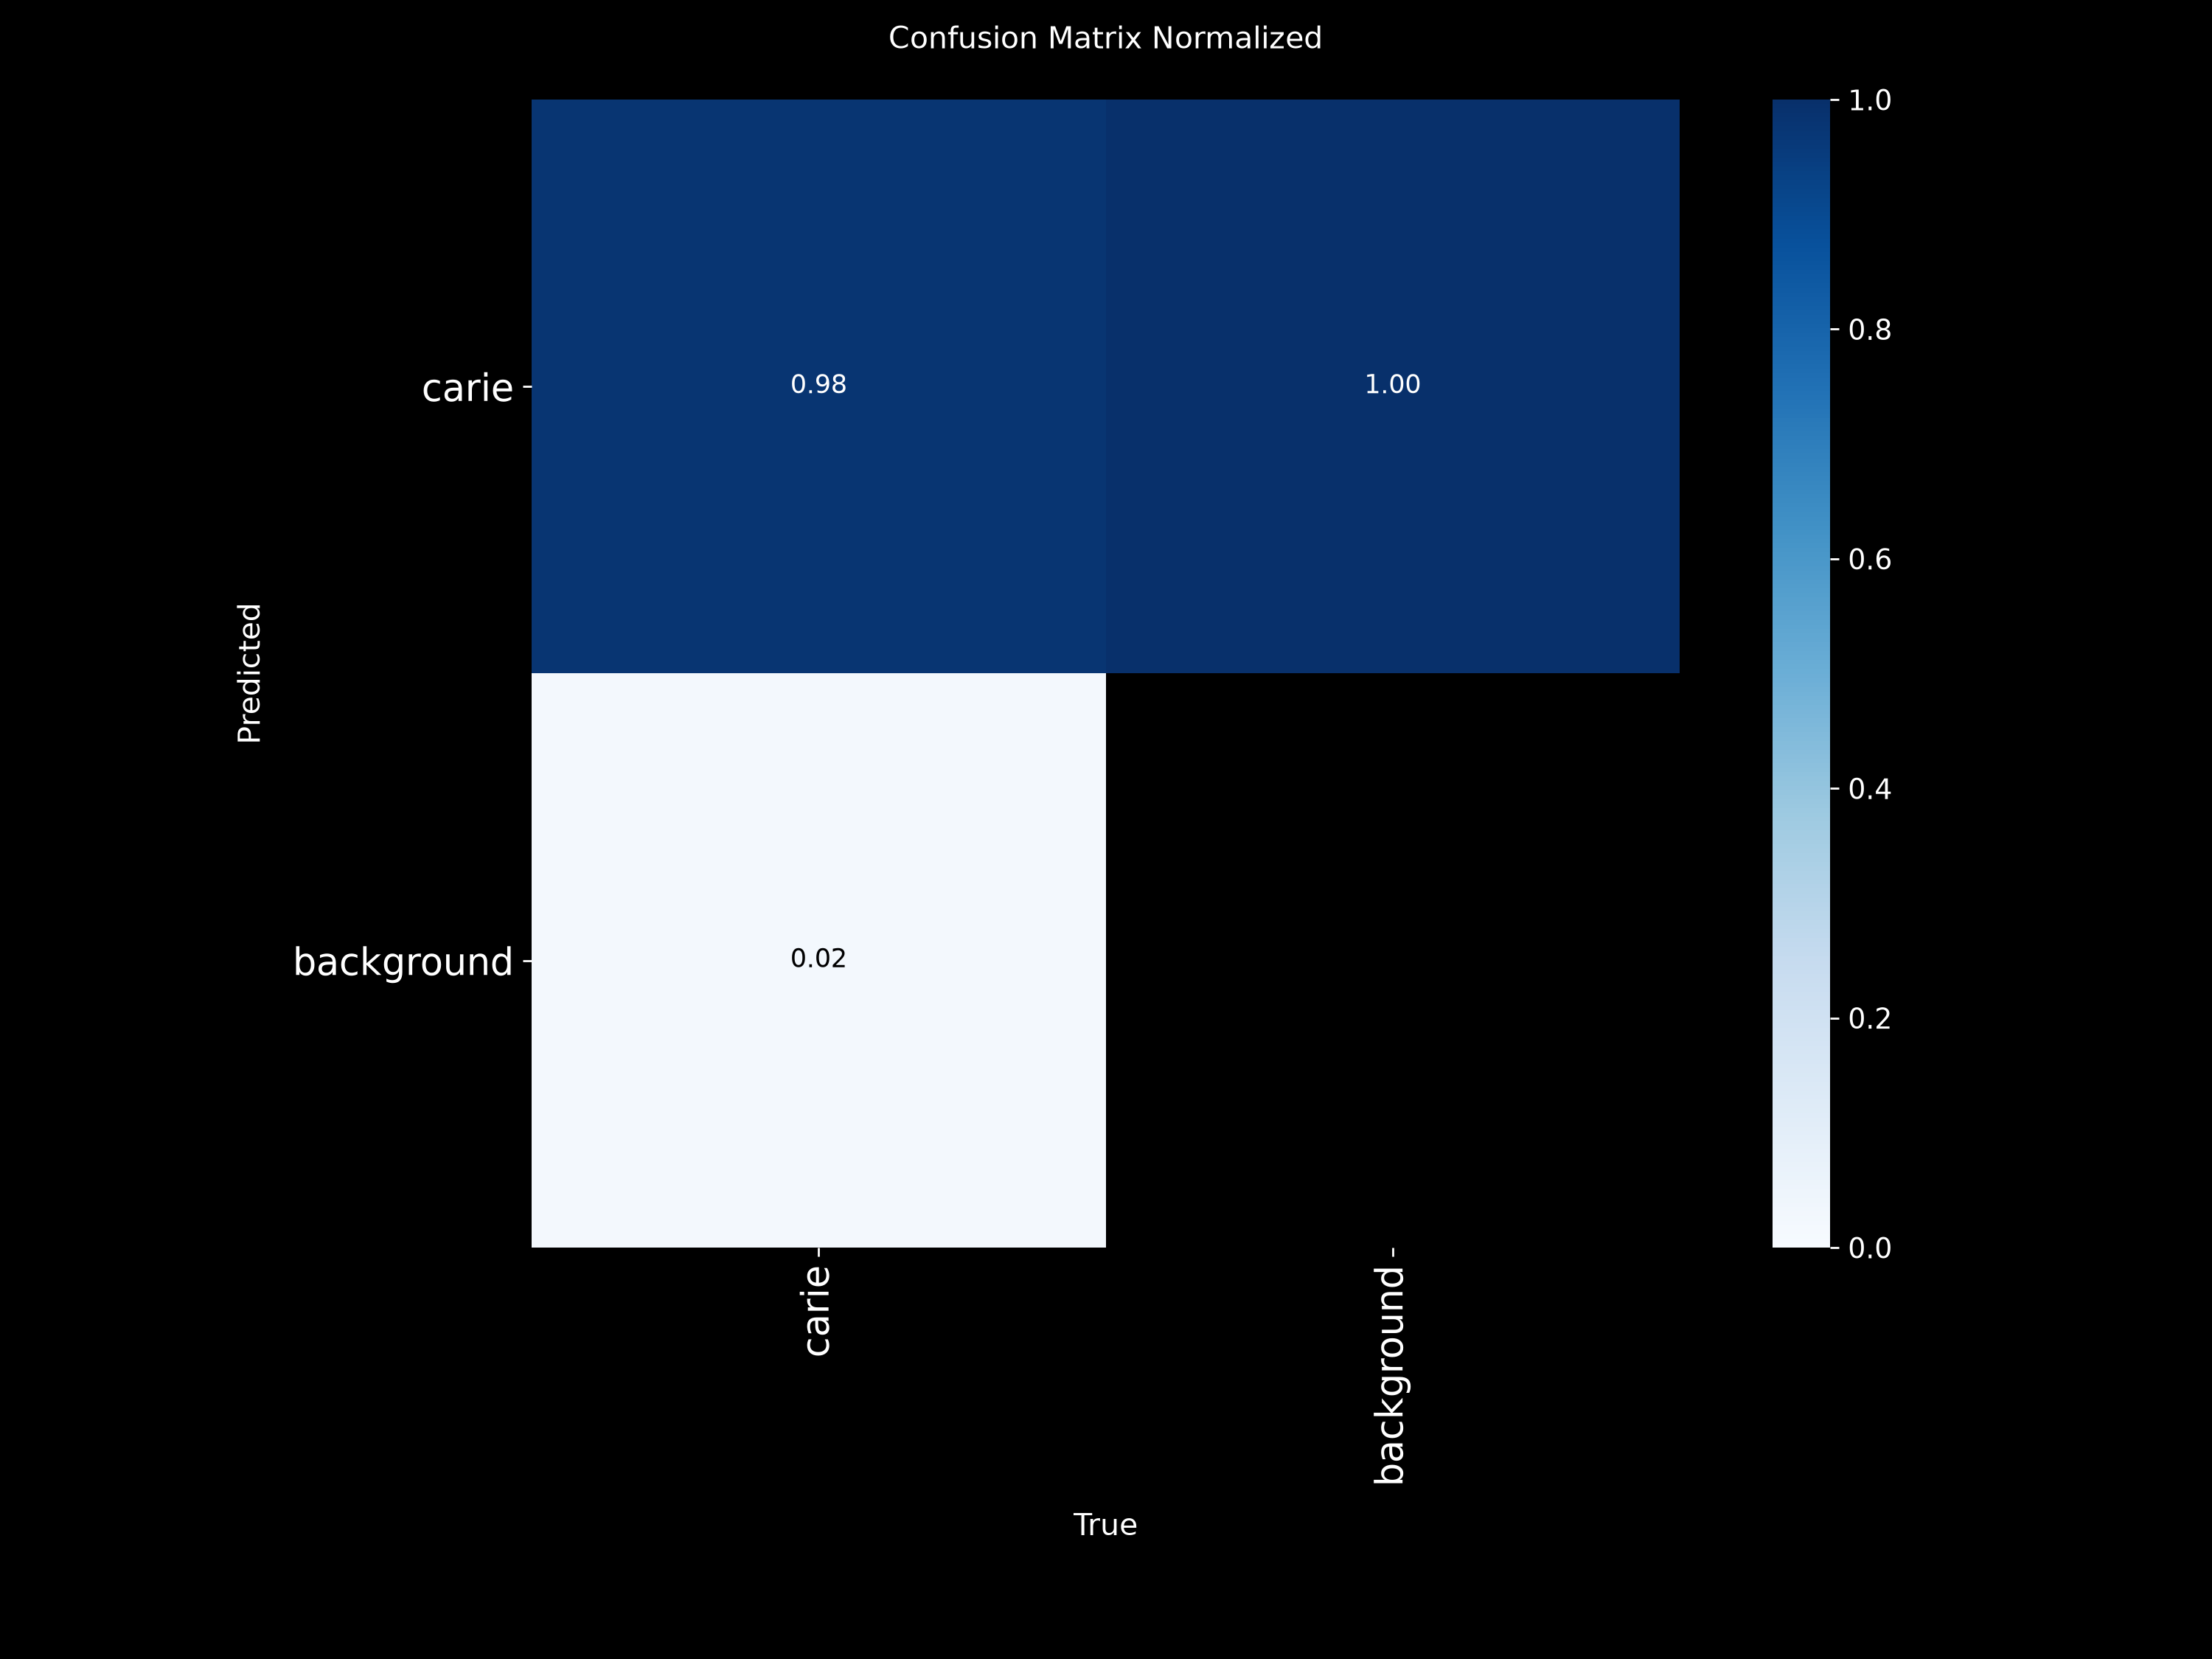


=== labels.jpg


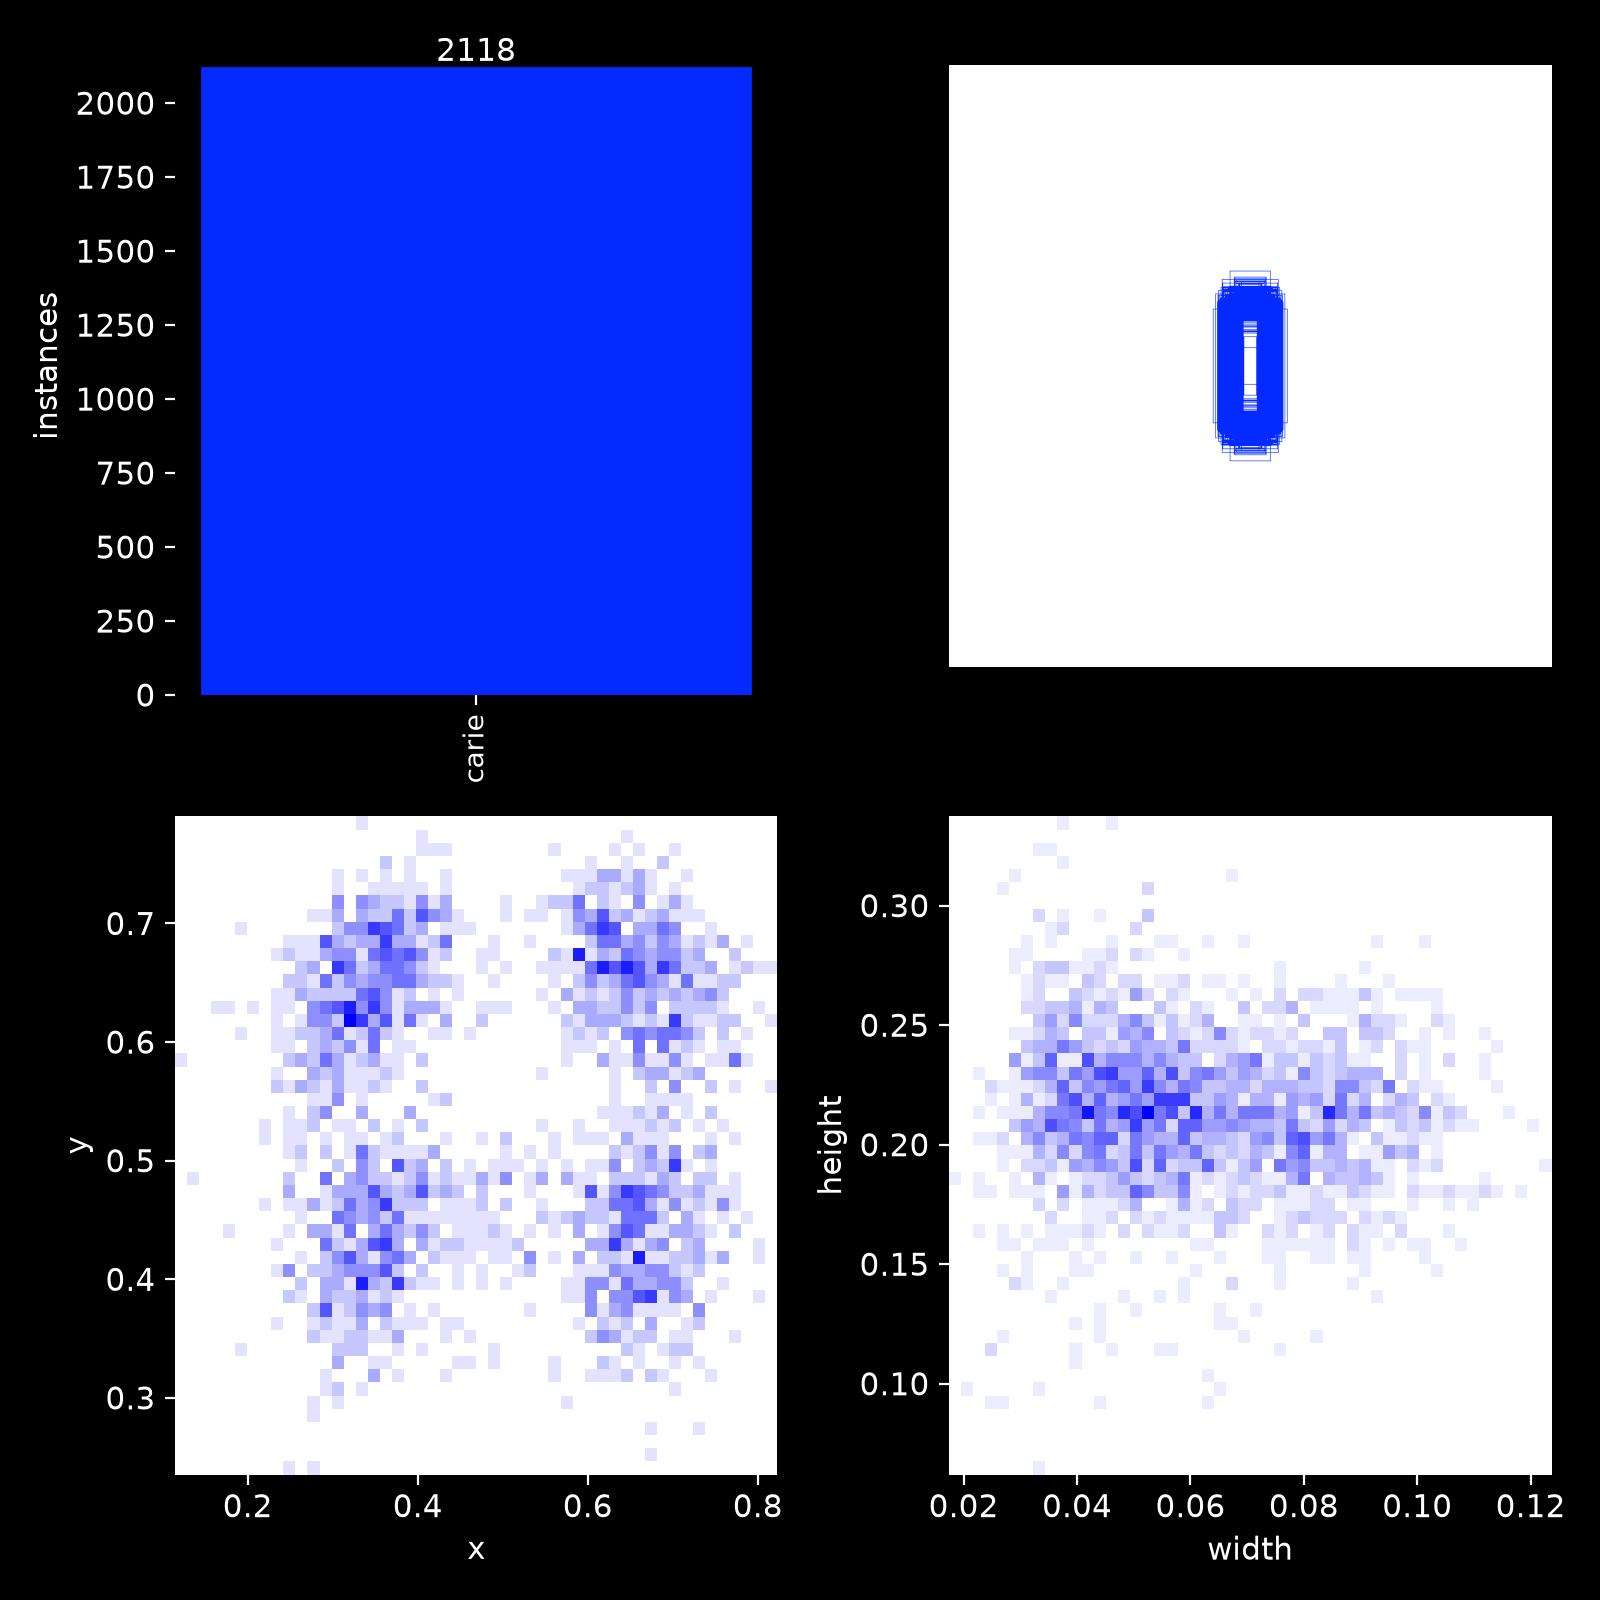


=== val_batch0_labels.jpg


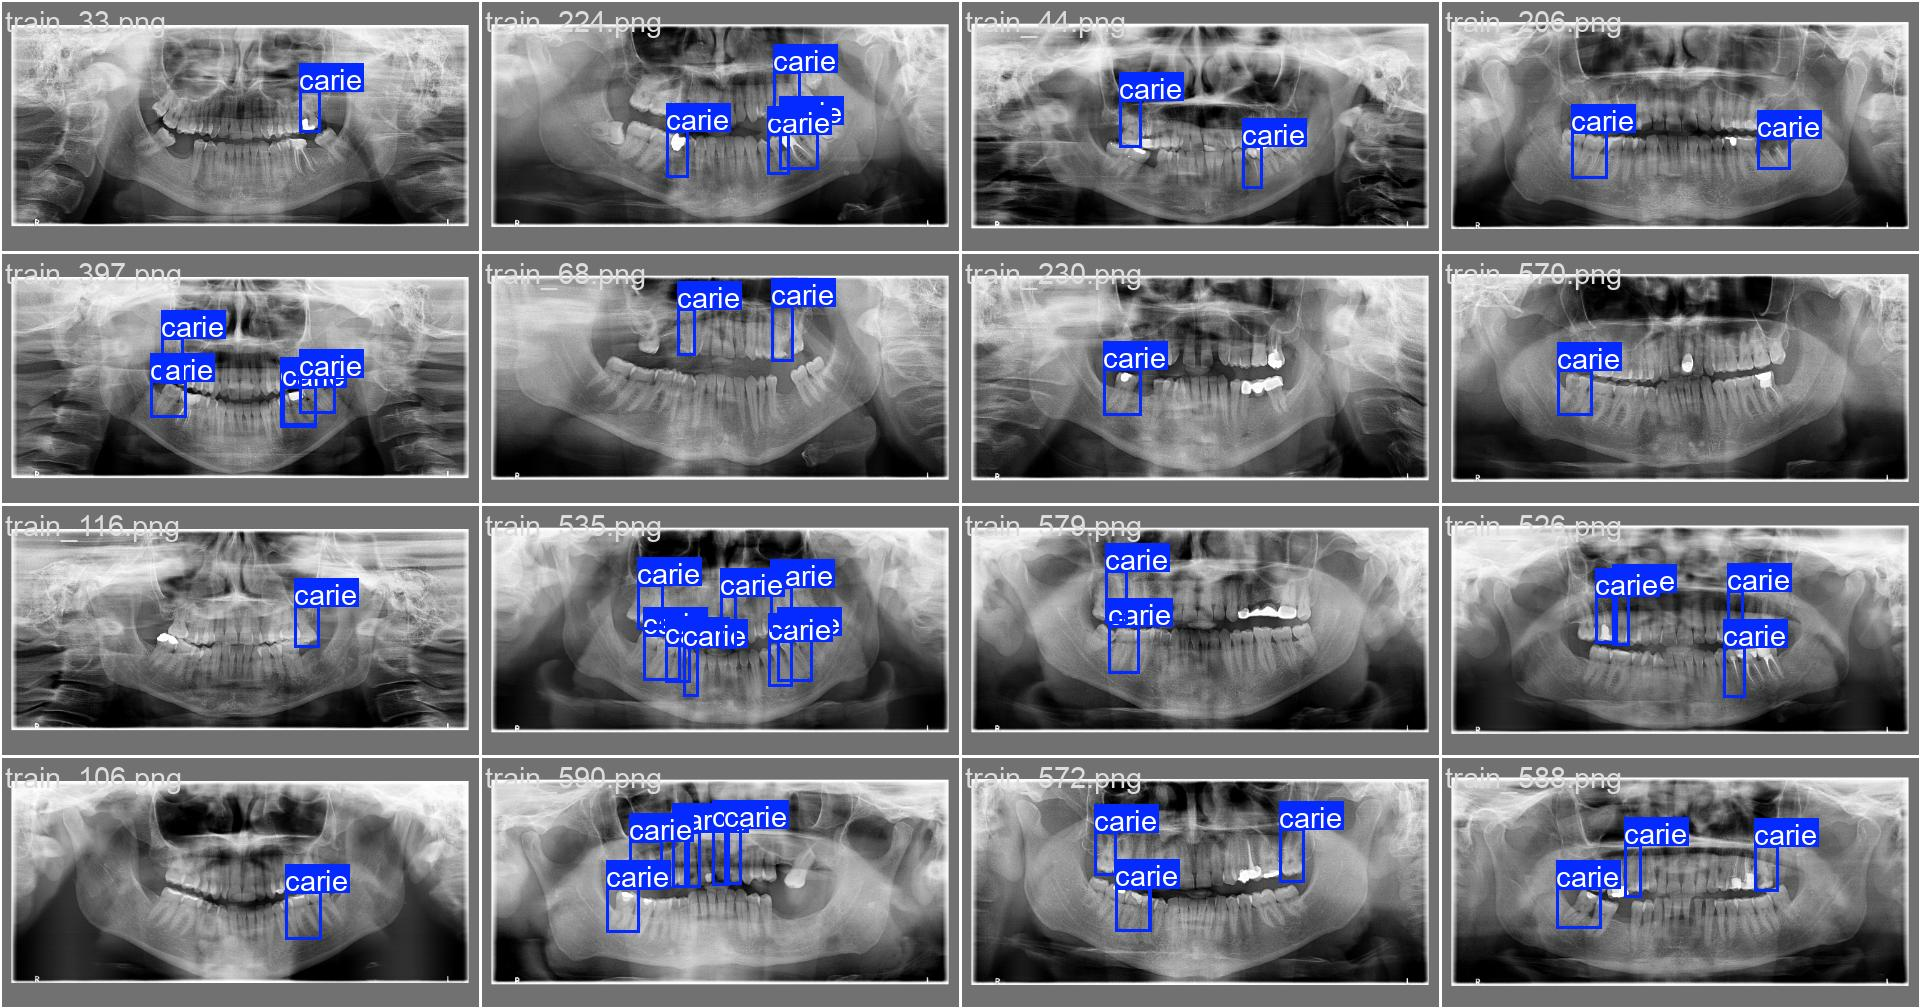


=== val_batch0_pred.jpg


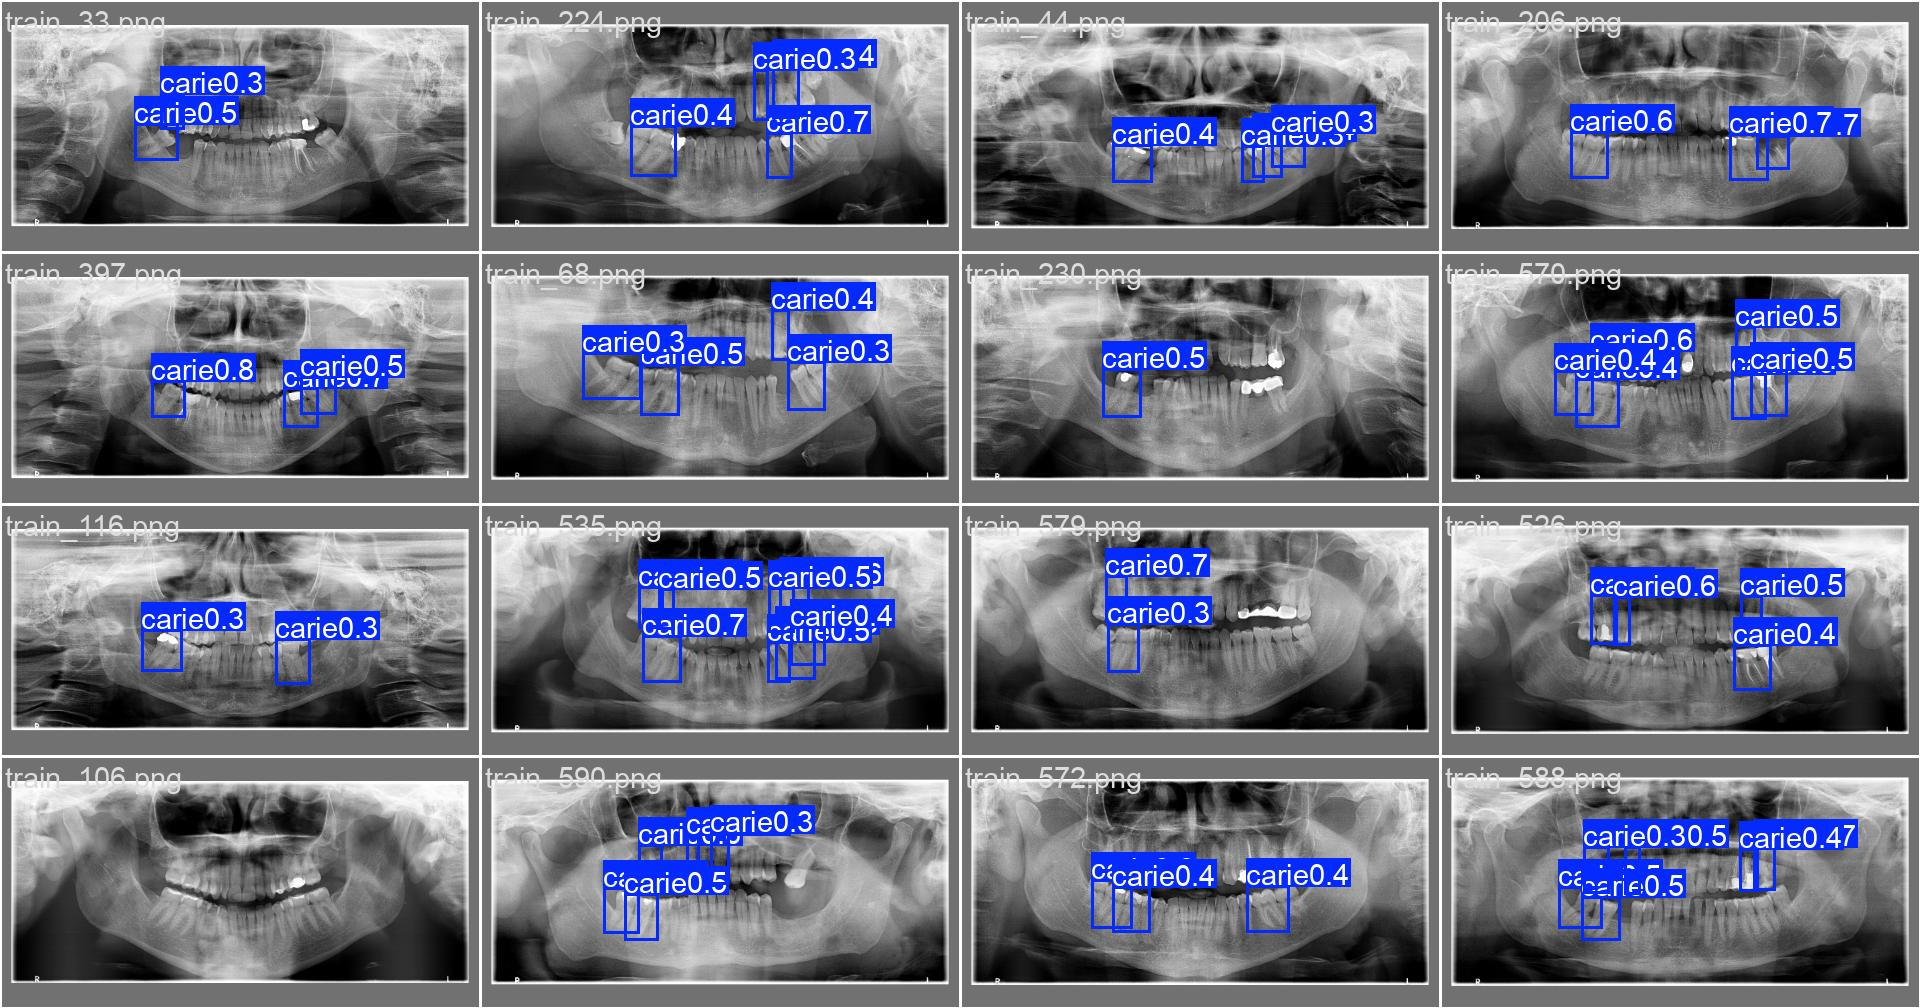

In [10]:
pasta = sorted(glob.glob("runs/detect/train*"))[-1]
print(pasta)

for nome in ["results.png", "PR_curve.png", "F1_curve.png",
             "confusion_matrix_normalized.png", "labels.jpg",
             "val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    arq = f"{pasta}/{nome}"
    if os.path.exists(arq):
        print("\n===", nome)
        display(Image(filename=arq, width=900))